# Notebook 03 – Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the dataset visually and statistically in order to understand feature distributions, relationships between variables, and factors associated with health condition.

The findings from this notebook will guide feature engineering and model selection."

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.data.loader import load_train_data, load_test_data
from src.profiling.profiler import DataProfiler

In [4]:
# ==========================================================
# Load Dataset
# ==========================================================

train = load_train_data()
test = load_test_data()

df = train.copy()

profiler = DataProfiler(df)

In [5]:
num_cols, cat_cols = profiler.feature_lists()

num_cols = [col for col in num_cols if col != "id"]

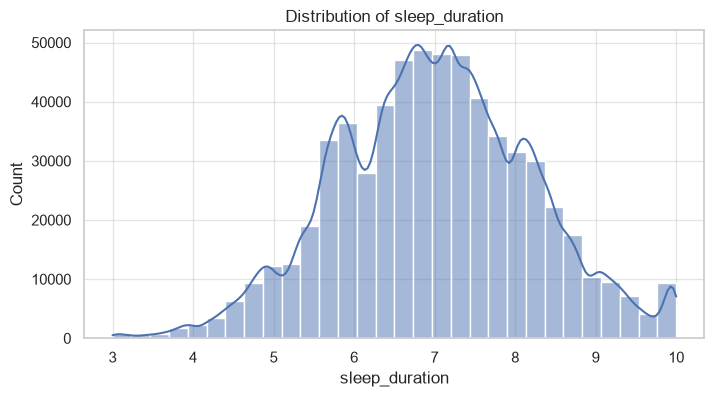

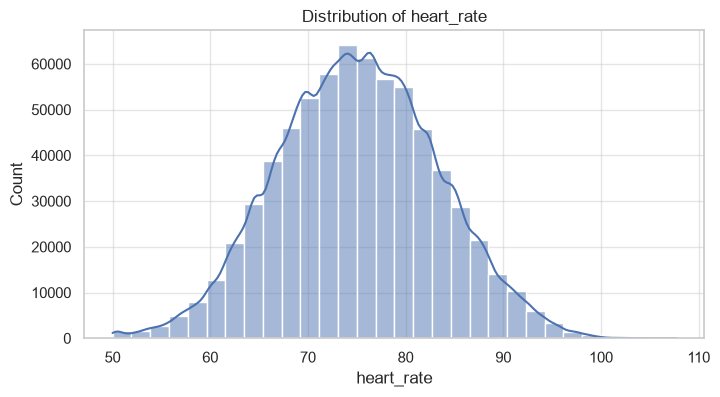

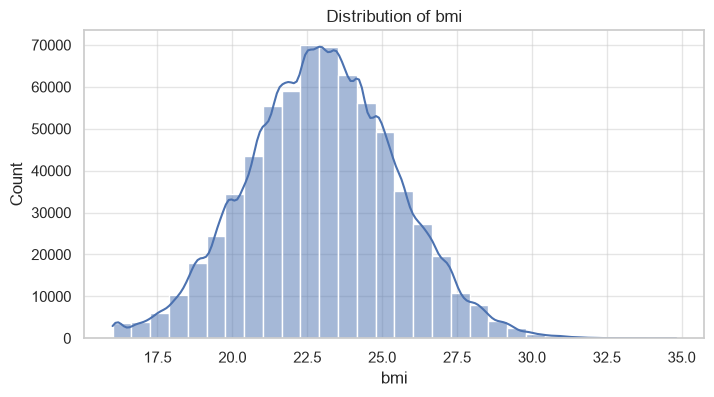

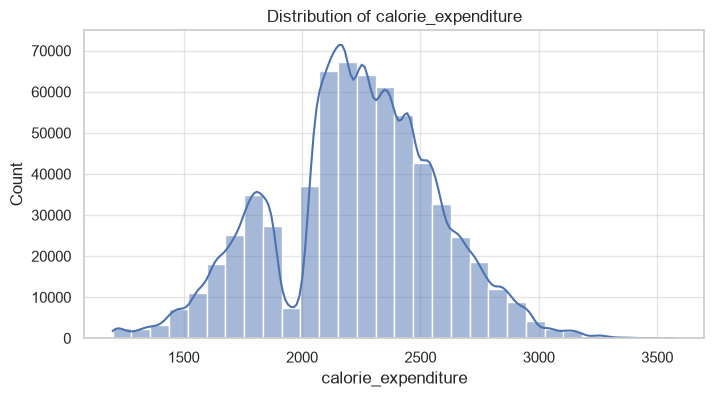

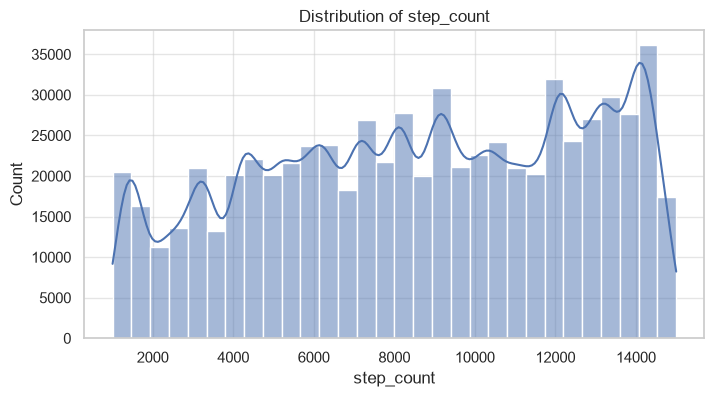

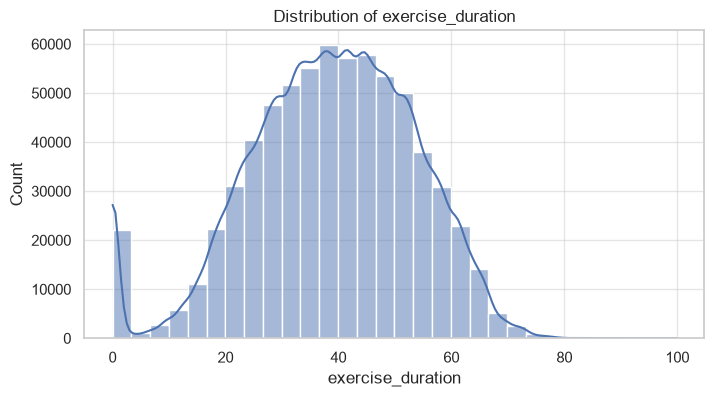

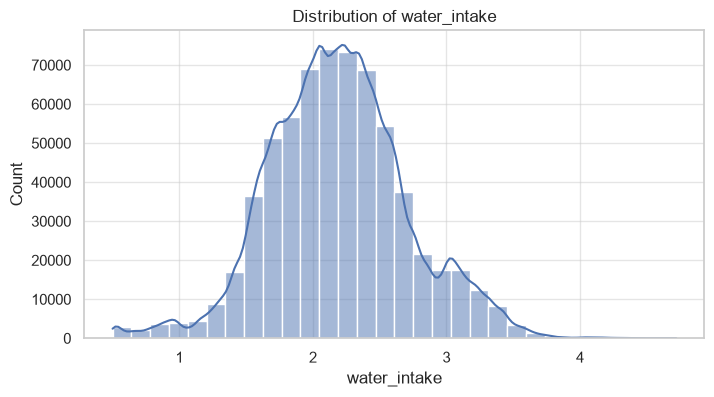

In [6]:
for column in num_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")

    plt.show()

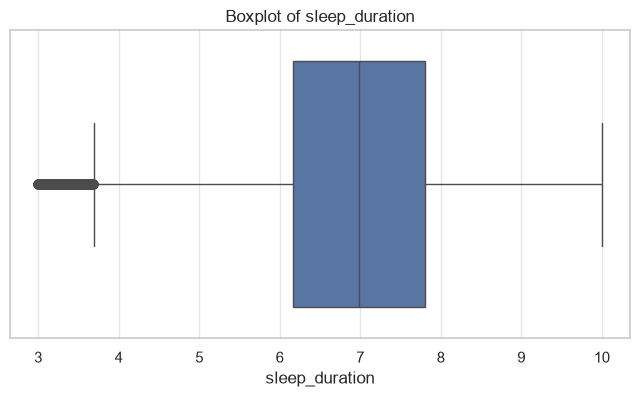

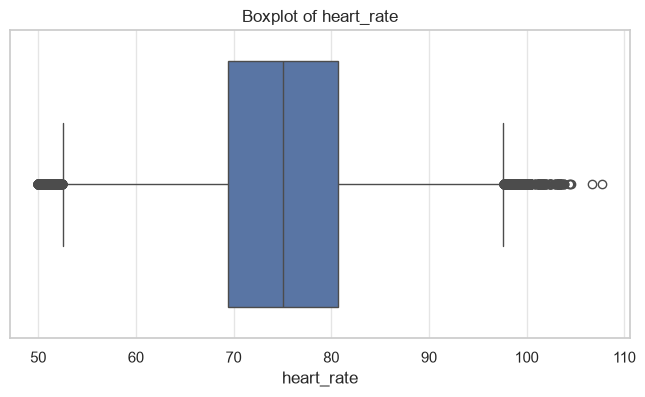

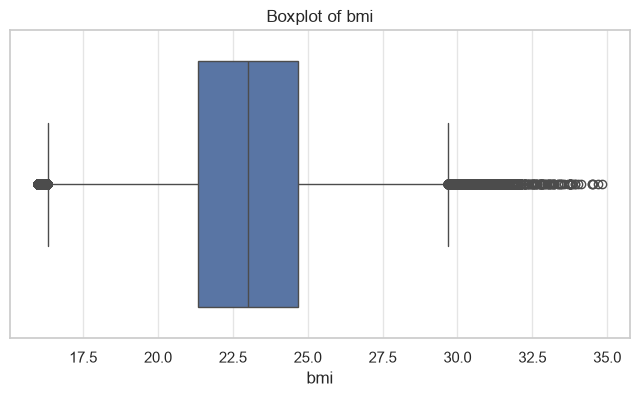

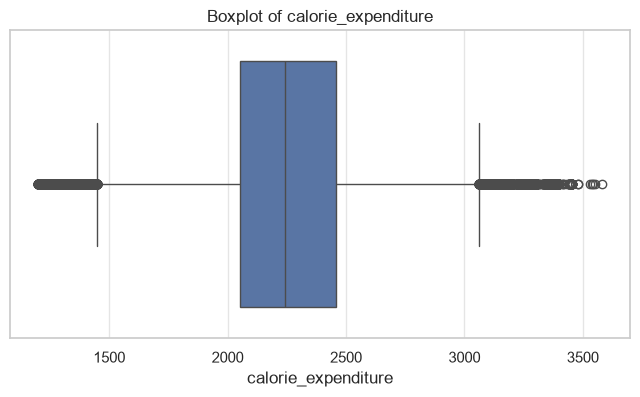

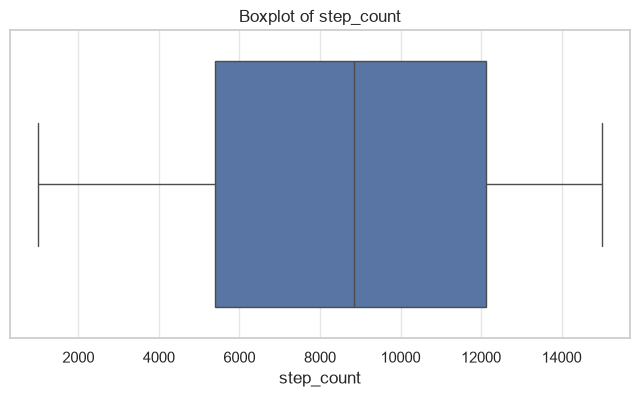

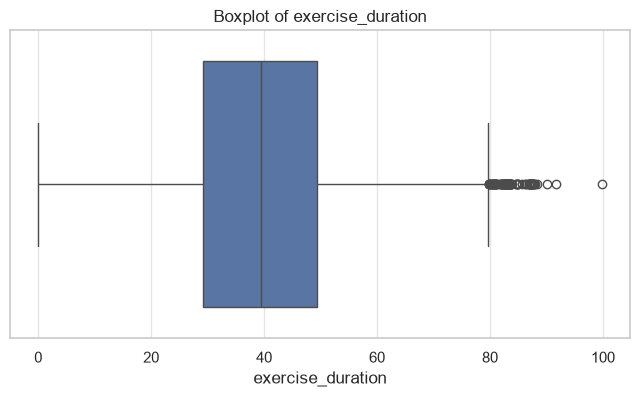

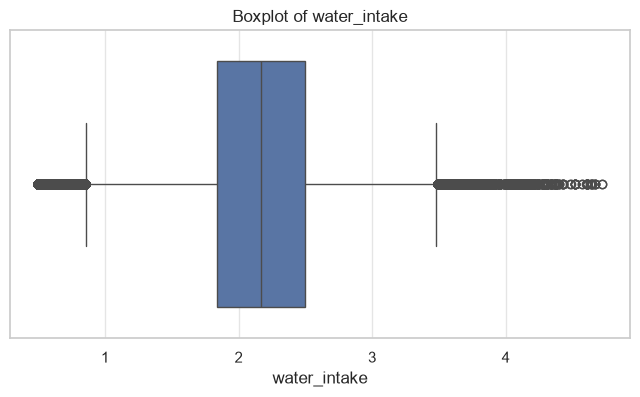

In [7]:
for column in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

In [8]:
skew_df = pd.DataFrame({

    "Feature":num_cols,

    "Skewness":[

        df[col].skew()

        for col in num_cols

    ]

})

display(skew_df.sort_values("Skewness"))

,Feature,Skewness
5,exercise_duration,-0.37
3,calorie_expenditure,-0.18
4,step_count,-0.18
0,sleep_duration,-0.01
1,heart_rate,0.00
2,bmi,0.02
6,water_intake,0.11


In [9]:
kurtosis_df = pd.DataFrame({

    "Feature":num_cols,

    "Kurtosis":[

        df[col].kurt()

        for col in num_cols

    ]

})

display(kurtosis_df)

,Feature,Kurtosis
0,sleep_duration,-0.11
1,heart_rate,-0.19
2,bmi,-0.03
3,calorie_expenditure,-0.06
4,step_count,-1.11
5,exercise_duration,0.03
6,water_intake,0.49


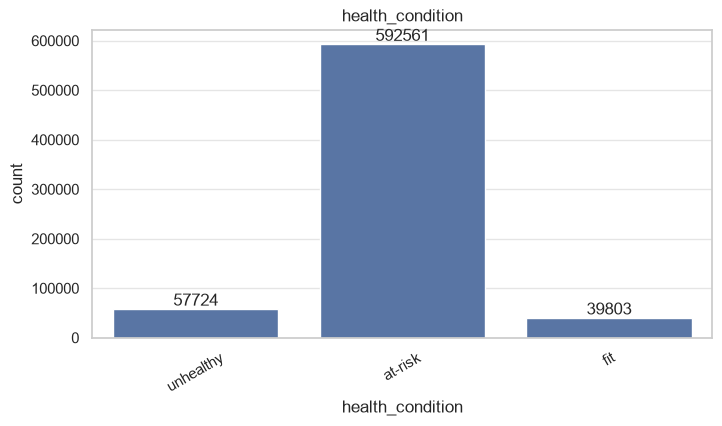

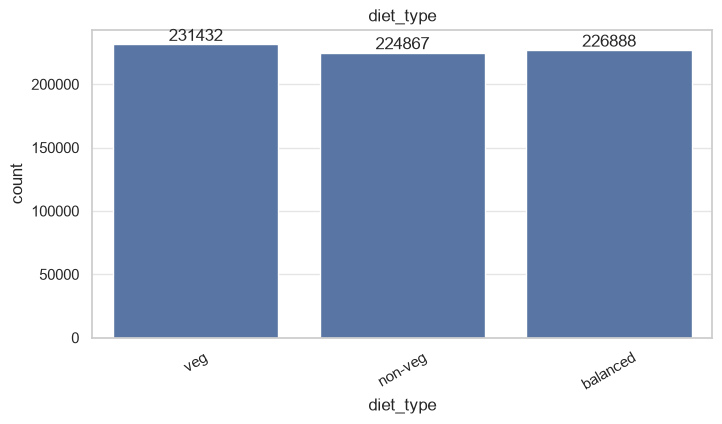

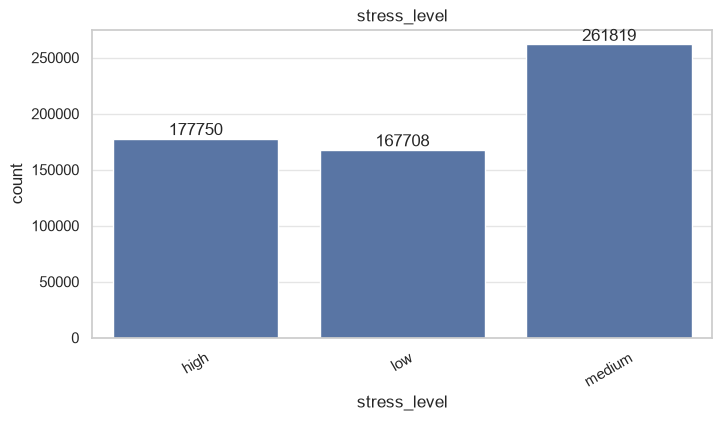

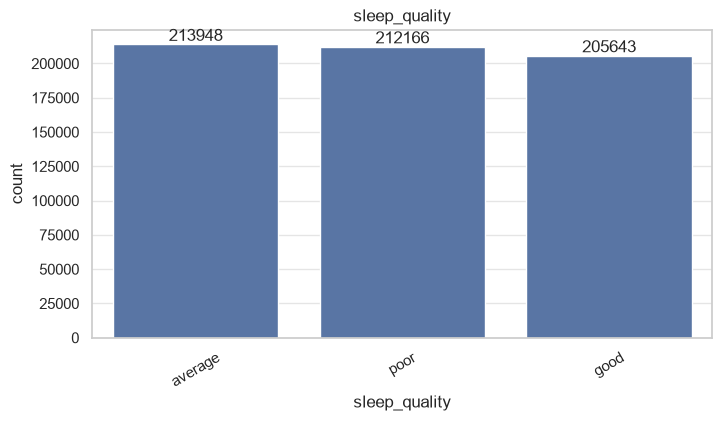

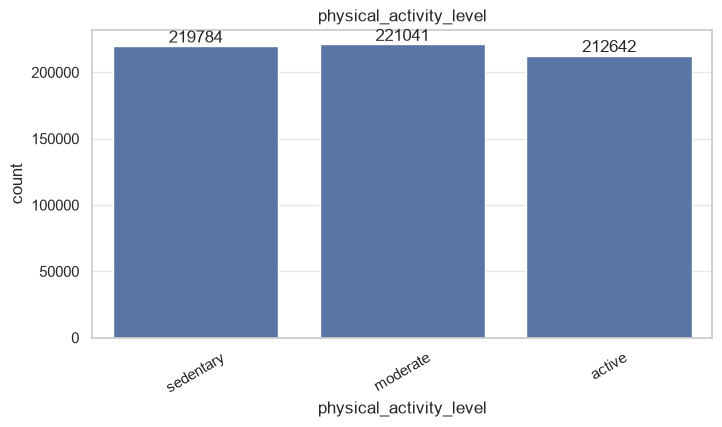

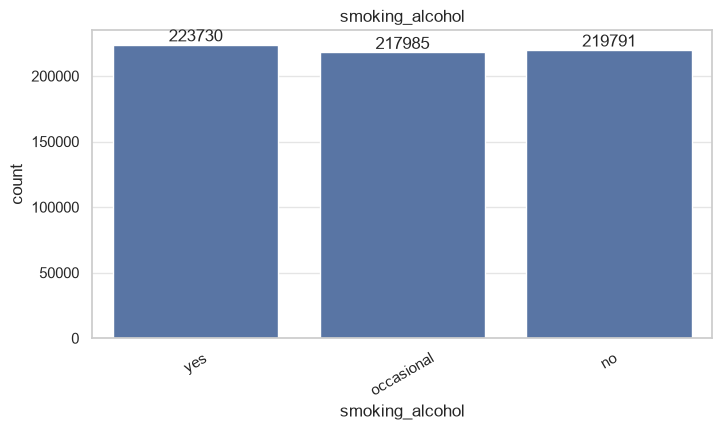

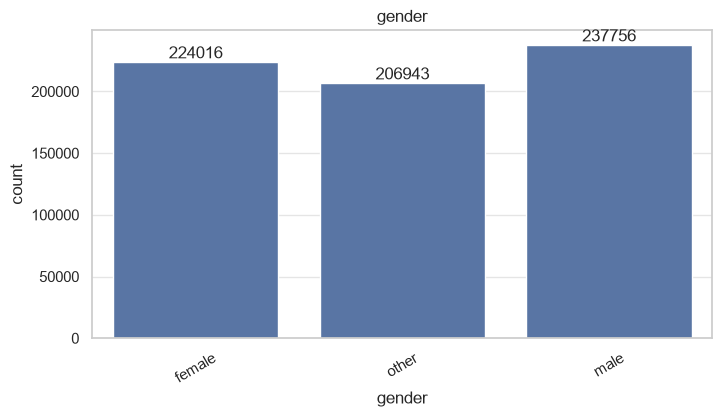

In [10]:
for column in cat_cols:

    plt.figure(figsize=(8,4))

    ax = sns.countplot(
        data=df,
        x=column
    )

    plt.title(column)

    for container in ax.containers:
        ax.bar_label(container)

    plt.xticks(rotation=30)

    plt.show()

## Business Insight

The distribution of diet types suggests that the dataset includes diverse dietary behaviours, enabling the model to learn potential relationships between nutrition and health condition.

# 6. Correlation Analysis

## Objective

Correlation analysis helps identify the strength and direction of linear relationships between numerical features.

Understanding these relationships is useful for:

- Detecting multicollinearity
- Understanding feature interactions
- Supporting feature engineering decisions
- Identifying redundant variables

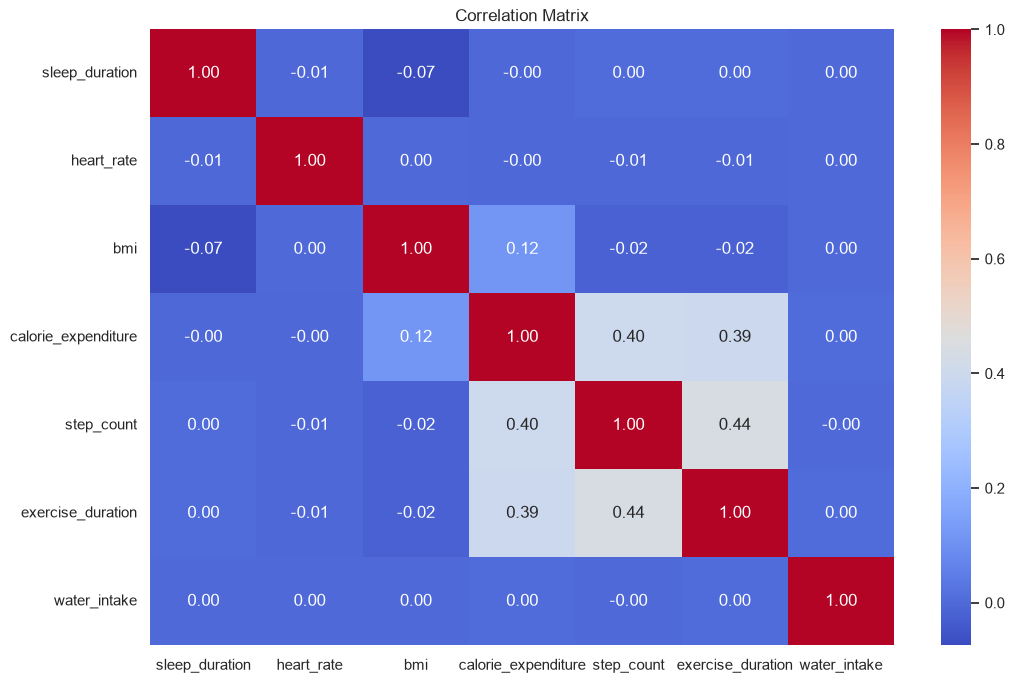

In [11]:
plt.figure(figsize=(12,8))

corr = df[num_cols].corr()

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

## Observations

1. Most numerical features exhibit weak linear correlations.

2. Step count and exercise duration show the strongest positive relationship (r = 0.44).

3. Calorie expenditure is moderately correlated with both exercise duration (r = 0.39) and step count (r = 0.40).

4. BMI has only a weak positive relationship with calorie expenditure (r = 0.12).

5. Water intake appears to be largely independent of the remaining numerical variables.

6. No pair of variables exhibits a correlation greater than 0.70, suggesting that severe multicollinearity is unlikely.

## Business Insight

The observed correlations align with expected physiological behaviour.

Individuals who exercise for longer durations generally record higher step counts and burn more calories.

Since no extremely high correlations are present, the numerical features appear to provide complementary information rather than redundant information. Therefore, all numerical variables will initially be retained for model development.

# 7. Statistical Analysis

## Numerical Features vs Health Condition (ANOVA)

Analysis of Variance (ANOVA) is used to determine whether the mean of a numerical feature differs significantly across the health-condition classes.

### Hypotheses

- **Null Hypothesis (H₀):** The mean values are equal across all health-condition groups.
- **Alternative Hypothesis (H₁):** At least one health-condition group has a different mean.

Decision Rule:

- p-value < 0.05 → Reject H₀ (Feature is significantly associated with health condition)
- p-value ≥ 0.05 → Fail to reject H₀

In [12]:
from scipy.stats import f_oneway

num_cols = [
    col for col in num_cols
    if col != "id"
]

anova_results = []

for column in num_cols:

    groups = [
        group[column].dropna()
        for _, group in df.groupby("health_condition")
    ]

    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        "Feature": column,
        "F Statistic": round(f_stat, 2),
        "P Value": round(p_value, 6),
        "Significant": p_value < 0.05
    })

anova_df = (
    pd.DataFrame(anova_results)
      .sort_values("P Value")
)

display(anova_df)

,Feature,F Statistic,P Value,Significant
0,sleep_duration,72549.60,0.00,True
1,heart_rate,36.32,0.00,True
2,bmi,10601.09,0.00,True
3,calorie_expenditure,3289.75,0.00,True
4,step_count,12944.80,0.00,True
5,exercise_duration,12864.80,0.00,True
6,water_intake,6.46,0.00,True


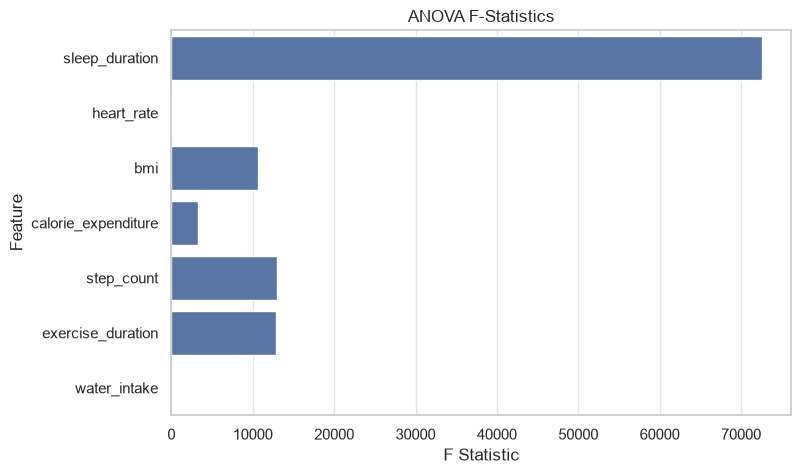

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=anova_df,
    x="F Statistic",
    y="Feature"
)

plt.title("ANOVA F-Statistics")

plt.show()

## Observations

1. Sleep duration exhibits the highest ANOVA F-statistic, indicating substantial differences across the health-condition classes.

2. Exercise duration and step count also demonstrate strong discriminatory power.

3. BMI shows a moderate but statistically significant relationship with the target.

4. Heart rate and water intake contribute relatively little to separating the health-condition groups.

5. Overall, several numerical variables differ significantly across the target classes and are likely to provide predictive information during model training.

## Categorical Features vs Health Condition (Chi-Square Test)

The Chi-Square Test evaluates whether categorical variables are associated with the target variable.

### Hypotheses

- **Null Hypothesis (H₀):** The categorical feature is independent of health condition.
- **Alternative Hypothesis (H₁):** The categorical feature is associated with health condition.

In [14]:
from scipy.stats import chi2_contingency

chi_results = []

for column in cat_cols:

    if column == "health_condition":
        continue

    contingency = pd.crosstab(
        df[column],
        df["health_condition"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    chi_results.append({

        "Feature": column,

        "Chi Square": round(chi2,2),

        "P Value": round(p,6),

        "Significant": p < 0.05

    })

chi_df = (
    pd.DataFrame(chi_results)
      .sort_values("P Value")
)

display(chi_df)

,Feature,Chi Square,P Value,Significant
0,diet_type,323.11,0.00,True
1,stress_level,206618.52,0.00,True
2,sleep_quality,18269.83,0.00,True
3,physical_activity_level,75816.23,0.00,True
4,smoking_alcohol,7715.70,0.00,True
5,gender,227.82,0.00,True


## Observations

1. All categorical variables have p-values below 0.05.

2. Stress level demonstrates the strongest association with health condition.

3. Physical activity level and sleep quality are also strongly associated with the target.

4. Diet type and gender are statistically significant but exhibit comparatively smaller chi-square statistics.

5. The results indicate that both lifestyle and demographic variables contribute to differentiating health-condition categories.

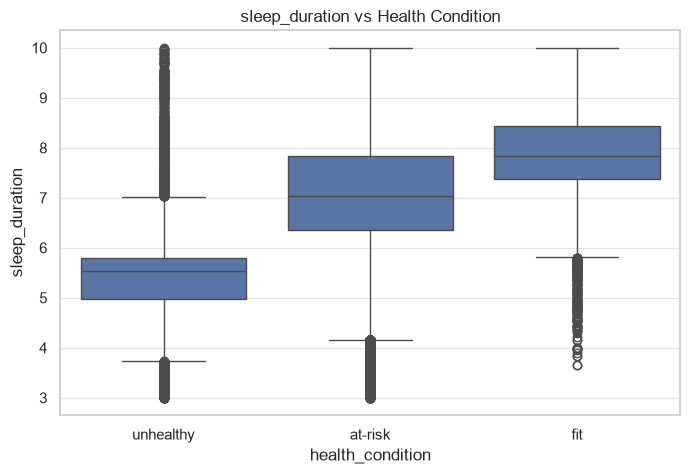

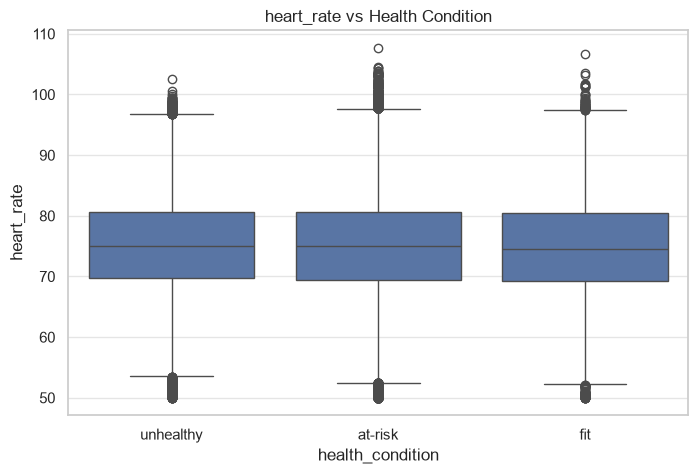

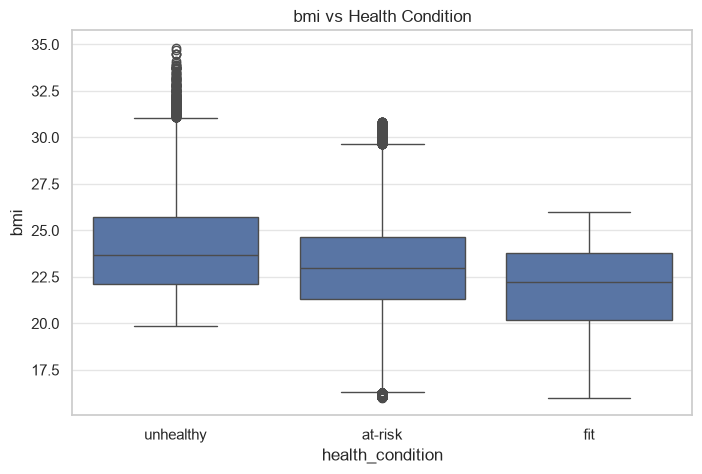

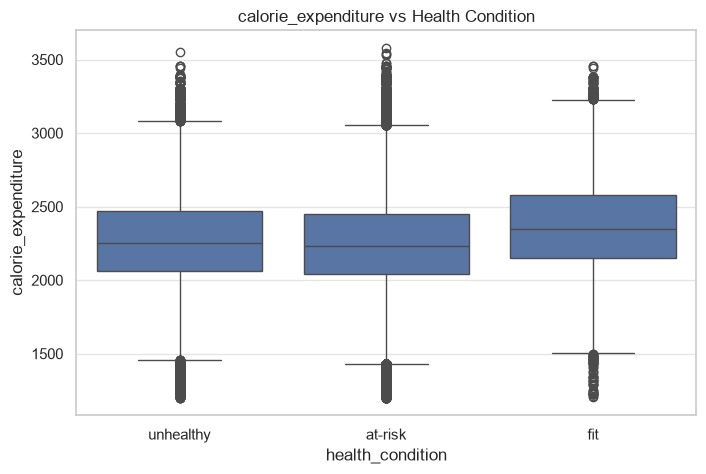

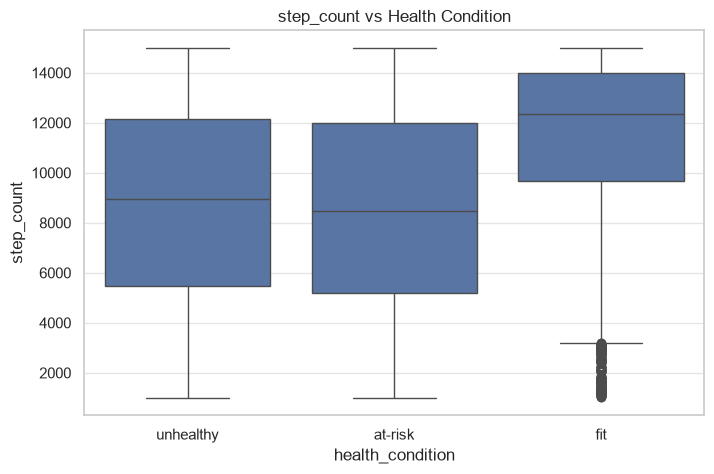

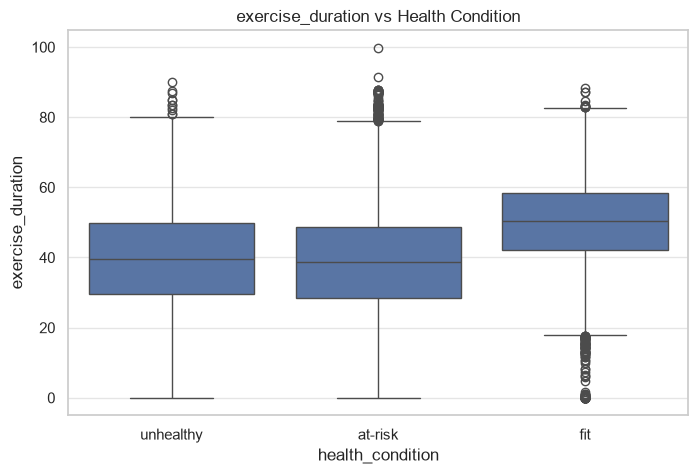

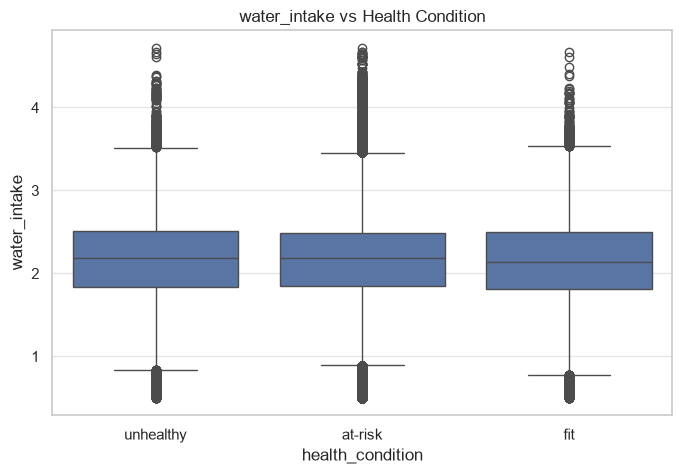

In [15]:
for column in num_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="health_condition",
        y=column
    )

    plt.title(f"{column} vs Health Condition")

    plt.show()

<Figure size 800x500 with 0 Axes>

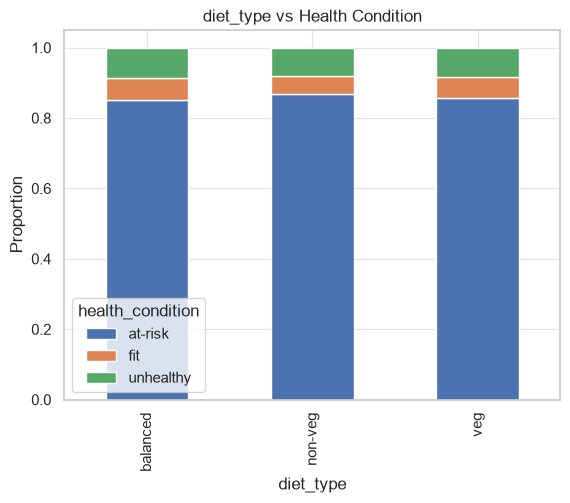

<Figure size 800x500 with 0 Axes>

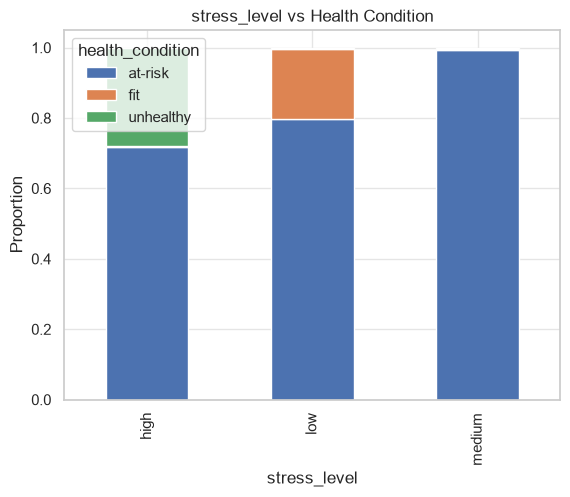

<Figure size 800x500 with 0 Axes>

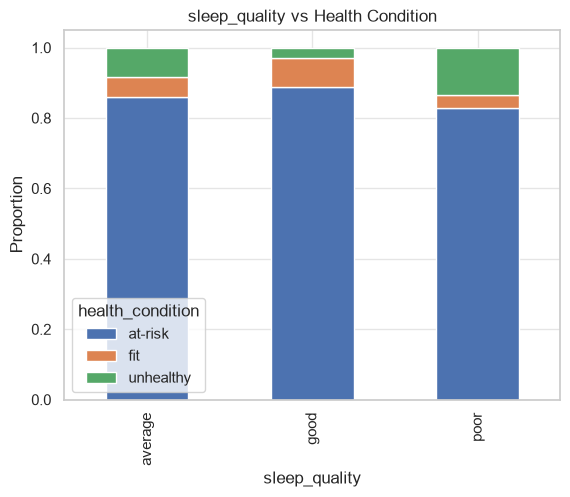

<Figure size 800x500 with 0 Axes>

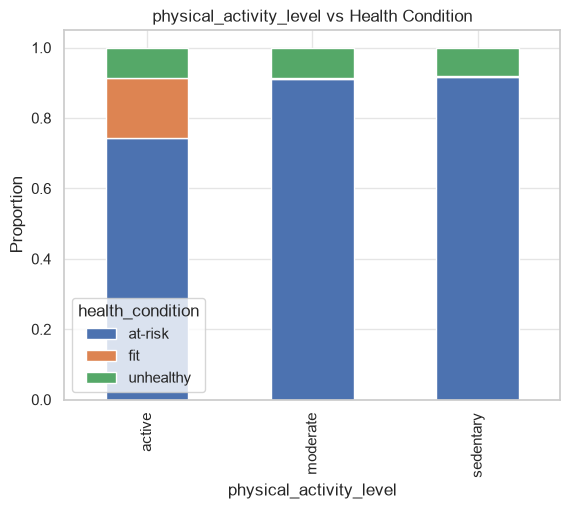

<Figure size 800x500 with 0 Axes>

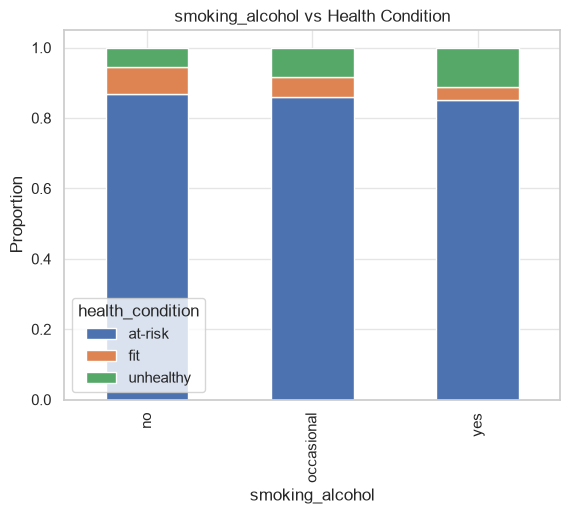

<Figure size 800x500 with 0 Axes>

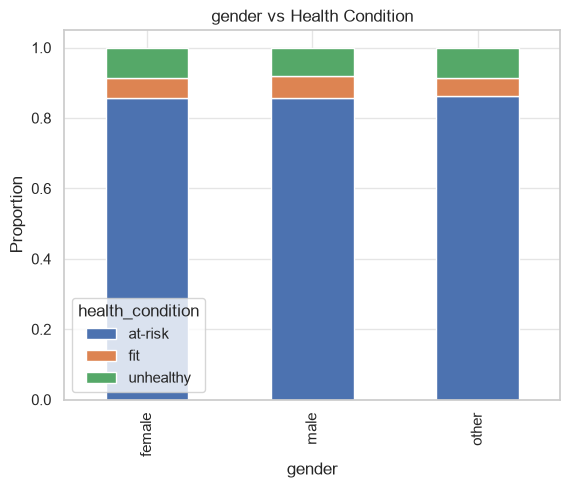

In [16]:
for column in cat_cols:

    if column == "health_condition":
        continue

    plt.figure(figsize=(8,5))

    cross = pd.crosstab(
        df[column],
        df["health_condition"],
        normalize="index"
    )

    cross.plot(
        kind="bar",
        stacked=True
    )

    plt.title(f"{column} vs Health Condition")
    plt.ylabel("Proportion")

    plt.show()

In [17]:
feature_summary = pd.DataFrame({

    "Feature": num_cols,

    "Skewness": [df[col].skew() for col in num_cols],

    "Missing (%)": [
        round(df[col].isnull().mean()*100,2)
        for col in num_cols
    ]

})

feature_summary = feature_summary.merge(

    anova_df[["Feature","P Value"]],

    on="Feature",

    how="left"

)

display(feature_summary)

,Feature,Skewness,Missing (%),P Value
0,sleep_duration,-0.01,11.01,0.00
1,heart_rate,0.00,1.14,0.00
2,bmi,0.02,2.01,0.00
3,calorie_expenditure,-0.18,7.66,0.00
4,step_count,-0.18,2.02,0.00
5,exercise_duration,-0.37,1.00,0.00
6,water_intake,0.11,6.30,0.00


# Key Insights

### Data Quality
- The dataset contains missing values in selected numerical features but no duplicate records.

### Feature Relationships
- Physical activity metrics (step count, exercise duration, calorie expenditure) show moderate positive relationships.
- Most numerical variables exhibit low multicollinearity.

### Statistical Findings
- Several numerical features demonstrate statistically significant differences across health-condition classes.
- Certain categorical variables also show significant associations with the target.

### Modelling Implications
- Feature engineering should address skewed variables where appropriate.
- Missing values should be imputed within the modelling pipeline.
- The target imbalance should be considered during model evaluation.

In [18]:
feature_ranking = pd.DataFrame({
    "Feature": num_cols,
    "Missing (%)": [
        round(df[col].isnull().mean() * 100, 2)
        for col in num_cols
    ],
    "Skewness": [
        round(df[col].skew(), 2)
        for col in num_cols
    ]
})

feature_ranking = feature_ranking.merge(
    anova_df[["Feature", "F Statistic", "P Value"]],
    on="Feature",
    how="left"
)

feature_ranking = feature_ranking.sort_values(
    by="F Statistic",
    ascending=False
)

display(feature_ranking)

,Feature,Missing (%),Skewness,F Statistic,P Value
0,sleep_duration,11.01,-0.01,72549.60,0.00
4,step_count,2.02,-0.18,12944.80,0.00
5,exercise_duration,1.00,-0.37,12864.80,0.00
2,bmi,2.01,0.02,10601.09,0.00
3,calorie_expenditure,7.66,-0.18,3289.75,0.00
1,heart_rate,1.14,0.00,36.32,0.00
6,water_intake,6.30,0.11,6.46,0.00


# Executive Summary

The exploratory analysis identified several meaningful relationships between the predictor variables and health condition.

## Key Findings

- Sleep duration emerged as the strongest numerical predictor.
- Exercise duration and step count also demonstrated strong associations with health condition.
- Stress level, sleep quality, and physical activity level were the most influential categorical variables.
- No evidence of severe multicollinearity was observed among the numerical features.
- Several numerical features exhibit skewness that may require transformation or robust scaling during preprocessing.
- The dataset contains both behavioural and physiological variables, providing complementary information for predictive modelling.

These findings will guide the feature engineering and modelling steps in the next notebook.